Control group conversion rate: 12.0%
Variant group conversion rate: 13.5%
Expected uplift: 12.5%
First 10 rows of the simulated data:
   user_id    group  converted
0        1  Control          0
1        2  Control          1
2        3  Control          0
3        4  Control          0
4        5  Control          0
5        6  Control          0
6        7  Control          0
7        8  Control          0
8        9  Control          0
9       10  Control          0

Group Statistics:
         count    mean  sum
group                      
Control   5000  0.1156  578
Variant   5000  0.1276  638
T-Test Results:
T-statistic: -1.8360
P-value: 0.066390
Significance level (α): 0.05

Interpretation:
❌ NOT STATISTICALLY SIGNIFICANT: We fail to reject the null hypothesis.
The difference in conversion rates between Control and Variant groups is not statistically significant.

Control Group: 11.560% conversion rate
Variant Group: 12.760% conversion rate
Absolute difference: 1.200%
Relative u

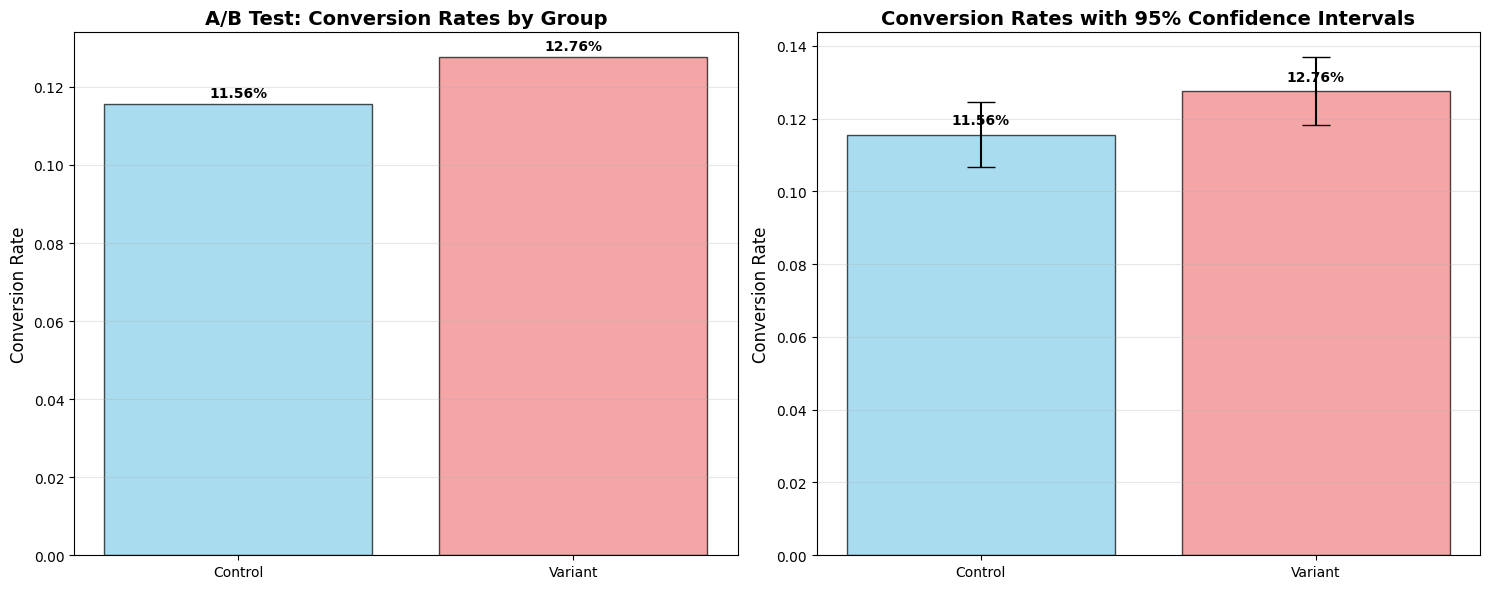

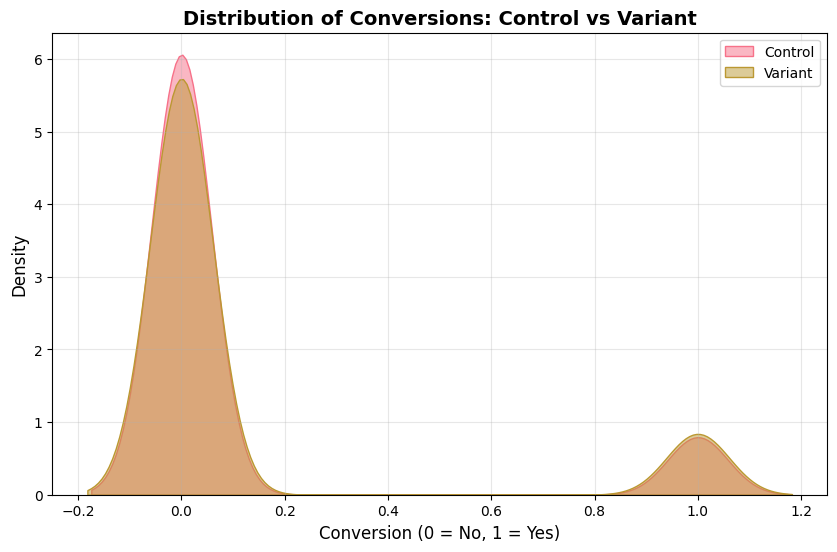

Business Impact Analysis (Monthly):
Current conversions: 11,560
Expected conversions with variant: 12,760
Additional conversions: 1,200
Current revenue: $578,000.00
Expected revenue with variant: $638,000.00
Revenue increase: $60,000.00
A/B TEST RESULTS SUMMARY
Sample size: 10,000 users total
Control conversion rate: 11.560%
Variant conversion rate: 12.760%
Absolute difference: 1.200%
Relative uplift: 10.4%
P-value: 0.066390
Statistical significance: NO
🔄 RECOMMENDATION: Do not implement the Variant version
The test does not show statistically significant improvement.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.stats import ttest_ind
import seaborn as sns
np.random.seed(42)
n_control = 5000     
n_variant = 5000      
control_rate = 0.12  
variant_rate = 0.135 

print(f"Control group conversion rate: {control_rate:.1%}")
print(f"Variant group conversion rate: {variant_rate:.1%}")
print(f"Expected uplift: {(variant_rate - control_rate)/control_rate:.1%}")
control_conversions = np.random.binomial(1, control_rate, n_control)
variant_conversions = np.random.binomial(1, variant_rate, n_variant)

# Create DataFrame
df_control = pd.DataFrame({
    'user_id': range(1, n_control + 1),
    'group': 'Control',
    'converted': control_conversions
})

df_variant = pd.DataFrame({
    'user_id': range(n_control + 1, n_control + n_variant + 1),
    'group': 'Variant',
    'converted': variant_conversions
})

# Combine into single DataFrame
df = pd.concat([df_control, df_variant], ignore_index=True)

# Display first few rows
print("First 10 rows of the simulated data:")
print(df.head(10))
group_stats = df.groupby('group')['converted'].agg(['count', 'mean', 'sum'])
group_stats['mean'] = group_stats['mean'].round(4)
print("\nGroup Statistics:")
print(group_stats)
control_data = df[df['group'] == 'Control']['converted']
variant_data = df[df['group'] == 'Variant']['converted']

# Independent t-test
t_stat, p_value = ttest_ind(control_data, variant_data)

print("T-Test Results:")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.6f}")
print(f"Significance level (α): 0.05")

# %%
# Interpretation
print("\nInterpretation:")
if p_value < 0.05:
    print("✅ STATISTICALLY SIGNIFICANT: We reject the null hypothesis.")
    print("The difference in conversion rates between Control and Variant groups is statistically significant.")
else:
    print("❌ NOT STATISTICALLY SIGNIFICANT: We fail to reject the null hypothesis.")
    print("The difference in conversion rates between Control and Variant groups is not statistically significant.")

# Calculate confidence intervals
control_mean = control_data.mean()
variant_mean = variant_data.mean()

control_se = control_data.std() / np.sqrt(len(control_data))
variant_se = variant_data.std() / np.sqrt(len(variant_data))

control_ci = stats.norm.interval(0.95, loc=control_mean, scale=control_se)
variant_ci = stats.norm.interval(0.95, loc=variant_mean, scale=variant_se)

print(f"\nControl Group: {control_mean:.3%} conversion rate")
print(f"Variant Group: {variant_mean:.3%} conversion rate")
print(f"Absolute difference: {(variant_mean - control_mean):.3%}")
print(f"Relative uplift: {((variant_mean - control_mean) / control_mean):.1%}")
plt.style.use('default')
sns.set_palette("husl")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
groups = ['Control', 'Variant']
conversion_rates = [control_mean, variant_mean]
colors = ['skyblue', 'lightcoral']

bars = ax1.bar(groups, conversion_rates, color=colors, alpha=0.7, edgecolor='black')
ax1.set_ylabel('Conversion Rate', fontsize=12)
ax1.set_title('A/B Test: Conversion Rates by Group', fontsize=14, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)
for bar, rate in zip(bars, conversion_rates):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.001,
             f'{rate:.2%}', ha='center', va='bottom', fontweight='bold')
x_pos = np.arange(len(groups))
ax2.bar(x_pos, conversion_rates, yerr=[control_mean - control_ci[0], variant_mean - variant_ci[0]], 
        capsize=10, color=colors, alpha=0.7, edgecolor='black')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(groups)
ax2.set_ylabel('Conversion Rate', fontsize=12)
ax2.set_title('Conversion Rates with 95% Confidence Intervals', fontsize=14, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

# Add value labels
for i, rate in enumerate(conversion_rates):
    ax2.text(i, rate + 0.002, f'{rate:.2%}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()
plt.figure(figsize=(10, 6))
sns.kdeplot(control_data, label='Control', fill=True, alpha=0.5)
sns.kdeplot(variant_data, label='Variant', fill=True, alpha=0.5)
plt.xlabel('Conversion (0 = No, 1 = Yes)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.title('Distribution of Conversions: Control vs Variant', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.show()
monthly_visitors = 100000
value_per_conversion = 50

current_conversions = monthly_visitors * control_mean
new_conversions = monthly_visitors * variant_mean

current_revenue = current_conversions * value_per_conversion
new_revenue = new_conversions * value_per_conversion

revenue_increase = new_revenue - current_revenue
conversion_increase = new_conversions - current_conversions

print("Business Impact Analysis (Monthly):")
print(f"Current conversions: {current_conversions:,.0f}")
print(f"Expected conversions with variant: {new_conversions:,.0f}")
print(f"Additional conversions: {conversion_increase:,.0f}")
print(f"Current revenue: ${current_revenue:,.2f}")
print(f"Expected revenue with variant: ${new_revenue:,.2f}")
print(f"Revenue increase: ${revenue_increase:,.2f}")
print("="*60)
print("A/B TEST RESULTS SUMMARY")
print("="*60)
print(f"Sample size: {n_control + n_variant:,} users total")
print(f"Control conversion rate: {control_mean:.3%}")
print(f"Variant conversion rate: {variant_mean:.3%}")
print(f"Absolute difference: {(variant_mean - control_mean):.3%}")
print(f"Relative uplift: {((variant_mean - control_mean) / control_mean):.1%}")
print(f"P-value: {p_value:.6f}")
print(f"Statistical significance: {'YES' if p_value < 0.05 else 'NO'}")
print("="*60)

if p_value < 0.05:
    print("🎯 RECOMMENDATION: Implement the Variant version")
    print("The test shows statistically significant improvement in conversion rate.")
else:
    print("🔄 RECOMMENDATION: Do not implement the Variant version")
    print("The test does not show statistically significant improvement.")
print("="*60)